In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import warnings 
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from kmodes.kmodes import KModes
from pyclustering.cluster.kmedoids import kmedoids
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

In [2]:
X, y = make_blobs(n_samples=100, centers=3, random_state=42, cluster_std=0.6)

In [3]:
df = pd.DataFrame(X, columns=['Feature_1', 'Feature_2'])
df

,Feature_1,Feature_2
0,-7.387703,-7.789018
1,5.127989,1.234651
2,-2.790882,9.339822
3,5.481555,1.132059
4,-6.664955,-6.543639
...,...,...
95,-2.915351,9.381292
96,-1.890598,9.573054
97,4.543107,2.215600
98,-6.229796,-6.247828


In [4]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [5]:
model_KM = KMeans(n_clusters=3, random_state=42)

In [6]:
cluster_labels = model_KM.fit_predict(X_scaled)

In [7]:
cluster_labels

array([1, 2, 0, 2, 1, 2, 0, 2, 2, 0, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 2, 1, 1, 1, 1, 2, 2, 1, 0, 0, 0, 0, 2, 2, 1, 0, 2, 0,
       0, 2, 1, 1, 1, 2, 2, 2, 0, 1, 1, 1, 0, 0, 2, 0, 1, 2, 1, 2, 1, 1,
       2, 1, 2, 2, 2, 1, 1, 0, 2, 1, 2, 1, 2, 2, 0, 2, 0, 1, 0, 0, 0, 2,
       0, 2, 2, 2, 0, 2, 0, 0, 0, 2, 1, 0], dtype=int32)

In [8]:
df['cluster'] = cluster_labels

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

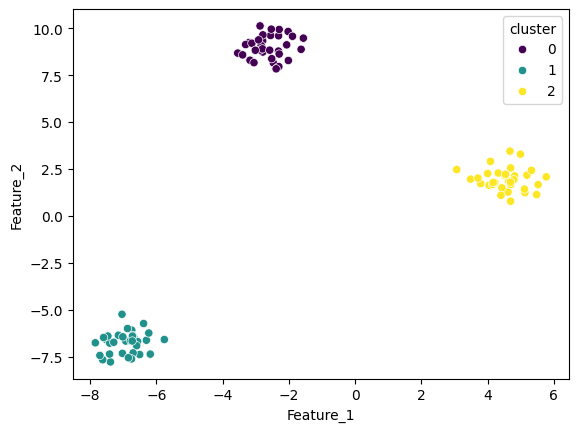

In [9]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['cluster'] ,palette='viridis')

In [10]:
#KMode
model_KD = KModes(n_clusters=3, random_state=42)

In [11]:
cluster_labels_KD = model_KD.fit_predict(X_scaled)
df['cluster_KD'] = cluster_labels_KD

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

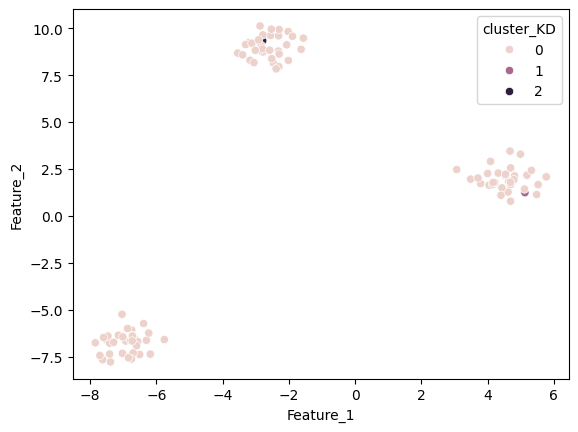

In [12]:
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['cluster_KD'])

In [13]:
#AGNES
from sklearn.cluster._agglomerative import AgglomerativeClustering

model_AGNES = AgglomerativeClustering(n_clusters=3)

In [14]:
cluster_labels_AGNES = model_AGNES.fit_predict(X_scaled)

<Axes: xlabel='Feature_1', ylabel='Feature_2'>

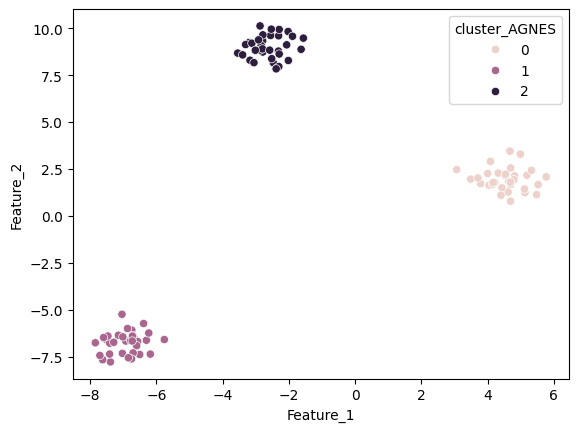

In [15]:
df['cluster_AGNES'] = cluster_labels_AGNES
sns.scatterplot(x=df['Feature_1'], y=df['Feature_2'], hue=df['cluster_AGNES'])

In [20]:
#KMedoid
data = X.tolist()
inital_medoids = [0,50,99]
model = kmedoids(data, inital_medoids, ccore=False)

In [21]:
model.process()
# X.shape

In [22]:
cluster_labels_KMD = model.get_clusters()

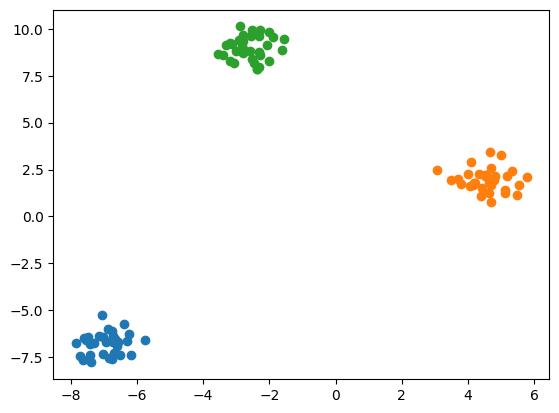

In [23]:
for cluster in cluster_labels_KMD:
    points = X[cluster]
    plt.scatter(points[:,0], points[:,1])

In [24]:
#DIANA